In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
#step 1 create synthetic datset (88 tourist activities)
states = ['concert', 'hike', 'restaurant', 'museum']

#transition probs (chosen arbitrarily for example)

#randomly gen the matrix
mat = np.random.rand(4, 4)

#normalize each row so the rows sum to 1
transition_probabilities = mat / mat.sum(axis = 1, keepdims = True)
print('transistion probabilities: ')
print(transition_probabilities)

np.random.seed(150)
num_steps = 88

activities = []
current_state = np.random.choice(states)
activities.append(current_state)

#generate synth sequence
for _ in range(num_steps - 1):
  idx = states.index(current_state)
  next_state = np.random.choice(states, p = transition_probabilities[idx])
  activities.append(next_state)
  current_state = next_state

transistion probabilities: 
[[0.4519018  0.17445367 0.10671571 0.26692882]
 [0.03867374 0.39286316 0.29038922 0.27807388]
 [0.13874635 0.41778021 0.04178677 0.40168667]
 [0.18021923 0.42129837 0.34864617 0.04983623]]


In [ ]:
#step 2 load dataset into python
df = pd.DataFrame({'activity': activities})
print('\nfirst 10 rows of synthetic dataset: ')
print(df.head(10))


first 10 rows of synthetic dataset: 
     activity
0     concert
1      museum
2        hike
3  restaurant
4        hike
5  restaurant
6      museum
7        hike
8  restaurant
9      museum


In [ ]:
#step 3 create table of conditional probs
transition_counts = pd.DataFrame(0, index = states, columns = states)

#count transitions
for i in range(len(activities) - 1):
  current = activities[i]
  next = activities[i + 1]
  transition_counts.loc[current, next] += 1

#convert counts -> probs
conditional_prob = transition_counts.div(transition_counts.sum(axis = 1), axis = 0)
conditional_prob = conditional_prob.fillna(0)

print('\ncoditional prob table:')
print(conditional_prob)


coditional prob table:
             concert      hike  restaurant    museum
concert     0.461538  0.461538    0.000000  0.076923
hike        0.000000  0.303030    0.515152  0.181818
restaurant  0.173913  0.347826    0.000000  0.478261
museum      0.111111  0.500000    0.333333  0.055556



transition matrix: 


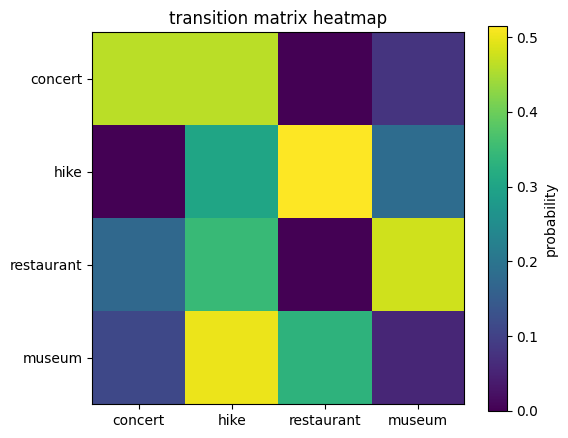

In [ ]:
#step 4 convert to transition matrix
transition_matrix = conditional_prob[states].to_numpy()
print('\ntransition matrix: ')

plt.figure(figsize = (6, 5))
plt.imshow(conditional_prob, cmap = 'viridis')
plt.colorbar(label = 'probability')
plt.title('transition matrix heatmap')
plt.xticks(range(4), ['concert', 'hike', 'restaurant', 'museum'])
plt.yticks(range(4), ['concert', 'hike', 'restaurant', 'museum'])
plt.show()

            concert  hike  restaurant  museum
concert           6     6           0       1
hike              0    10          17       6
restaurant        4     8           0      11
museum            2     9           6       1


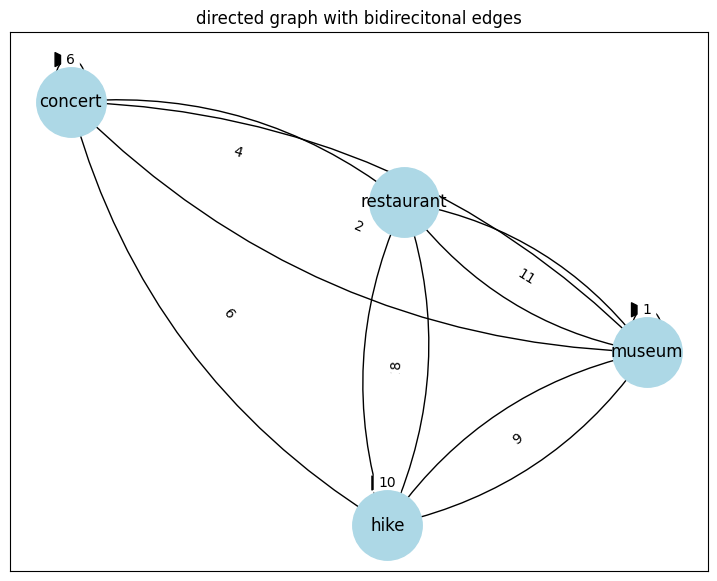

In [ ]:
#step 5 generate a graph illustrating the markov chain
G = nx.DiGraph()

#add edges with counts as weights
print(transition_counts)
for from_state in states:
  for to_state in states:
    weight = transition_counts.loc[from_state, to_state]
    if weight > 0:
      G.add_edge(from_state, to_state, weight = weight)

plt.figure(figsize = (9, 7))

#layout
pos = nx.spring_layout(G, seed = 42)

#draw nodes
nx.draw_networkx_nodes(G, pos, node_color = 'lightblue', node_size = 2500)
nx.draw_networkx_labels(G, pos)

#draw edges with curve style so reverse edges are visible
nx.draw_networkx_edges(
    G, pos,
    arrowstyle = '-|>',
    arrowsize = 25,
    connectionstyle = 'arc3, rad = 0.2' #curve edges
)

#draw edge labels
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data = True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)

plt.title('directed graph with bidirecitonal edges')
plt.show()

In [ ]:
#step 6 compute steady state probs
def compute_steady_state(P, tol = 1e-10, max_iter = 10000):
  n = P.shape[0]
  v = np.ones(n) / n #start with uniform dist
  for i in range(max_iter):
    new_v = v @ P
    if np.linalg.norm(new_v - v) < tol:
      return new_v, i
    v = new_v
  return v, max_iter

steady_state, iterations = compute_steady_state(transition_matrix)

print('\nsteady state probabilities: ')
for s, prob in zip(states, steady_state):
  print(f'{s}: {prob:.4f}')

print(f'\niterations needed to reach steady state: {iterations}')


steady state probabilities: 
concert: 0.1321
hike: 0.3793
restaurant: 0.2687
museum: 0.2198

iterations needed to reach steady state: 19


In [ ]:
#step 7 how lkely is a tourist to attend a concert, then go on a hike, then eat at a restaurant?

#learn theory and do it using pencil and paper in class

#access individual steady-state probs using their index from the steady_state array
concert_prob = steady_state[states.index('concert')]
hike_prob = steady_state[states.index('hike')]
restaurant_prob = steady_state[states.index('restaurant')]

#multiply probs we found in step 6 with each other (c, h, r)
likelihood = concert_prob * hike_prob * restaurant_prob

print(f'\nlikelihood of concert -> hike -> restaurant: {likelihood:.6f}')


likelihood of concert -> hike -> restaurant: 0.013468


In [ ]:
#step 8 fifth power of the transition matrix

#use transition_matrix computed earlier
P = transition_matrix

#starting prob vector (uniform)
#the assignment says 0.2 (x5), but we use 0.25 (x4)
spv = np.array([0.25, 0.25, 0.25, 0.25])

#compute p^5
P5 = np.linalg.matrix_power(P, 5)

#prob dist at step 5
step5_dist = spv @ P5

print('probability of being in each locaiton at step 5:')
for s, p in zip(states, step5_dist):
  print(f'{s}: {p:.4f}')

probability of being in each locaiton at step 5:
concert: 0.1325
hike: 0.3791
restaurant: 0.2684
museum: 0.2200


step 9 - Formulate the MCMC Question

- Given the observed sequence of 88 tourist activities, what is the posterior distribution of the transition probability from concert to hike, and what is its 95% credible interval?

In [ ]:
#step 10 - can be changed...?

#synthetic logistc data (replace with your real tourist data)
np.random.seed(42)

#x = encoded previos location (0-3)
x = np.random.randint(0, 4, size = 60)

true_alpha = 0.4
true_beta = -0.6

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

#y = 1 if next locaiton is "concert", else 0
y = np.random.binomial(1, sigmoid(true_alpha + true_beta * x))

#log likelihood
def log_likelihood(alpha, beta):
  p = sigmoid(alpha + beta * x)
  return np.sum(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))

#gausian prior n(0, 1)
def log_prior(alpha, beta):
  return -0.5 * (alpha**2 + beta**2)

#posterior
def log_posterior(alpha, beta):
  return log_likelihood(alpha, beta) + log_prior(alpha, beta)

#metropolis-hastings
iterations = 6000
alpha_chain = np.zeros(iterations)
beta_chain = np.zeros(iterations)

#step (a) initial values
alpha_chain[0] = 0.0
beta_chain[0] = 0.0

proposal_sd = 0.3

for t in range(1, iterations):
  current_alpha = alpha_chain[t-1]
  current_beta = beta_chain[t-1]

  #step (b) propose new values
  proposed_alpha = np.random.normal(current_alpha, proposal_sd)
  proposed_beta = np.random.normal(current_beta, proposal_sd)

  #step (c) acceptance probability
  current_post = log_posterior(current_alpha, current_beta)
  proposed_post = log_posterior(proposed_alpha, proposed_beta)

  accept_ratio = np.exp(proposed_post - current_post)

  if np.random.rand() < accept_ratio:
    alpha_chain[t] = proposed_alpha
    beta_chain[t] = proposed_beta
  else:
    alpha_chain[t] = current_alpha
    beta_chain[t] = current_beta

estimated alpha: 0.3418584193939978
estimated beta: -0.5154930531689528

 95% Credibility Interval
[-0.51915929  1.11671151]
[-0.93263957 -0.08673416]


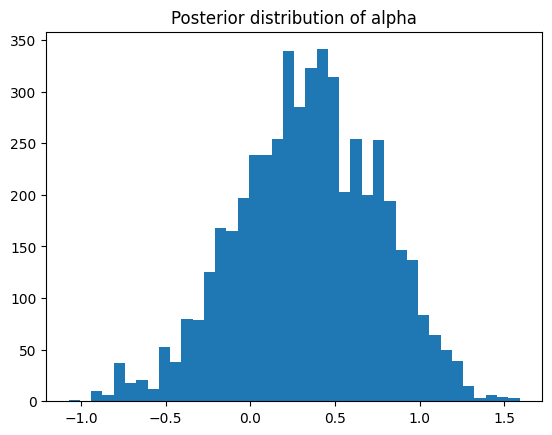

In [ ]:
#step 11 posterior means

#remove burn-in
burn_in = 1000
alpha_samples = alpha_chain[burn_in:]
beta_samples = beta_chain[burn_in:]

alpha_est = np.mean(alpha_samples)
beta_est = np.mean(beta_samples)

print('estimated alpha: ' + str(alpha_est))
print('estimated beta: ' + str(beta_est))

print('\n 95% Credibility Interval')
print(np.percentile(alpha_samples, [2.5, 97.5]))
print(np.percentile(beta_samples, [2.5, 97.5]))

plt.hist(alpha_samples, bins=40)
plt.title("Posterior distribution of alpha")
plt.show()

step 12 - Interpret the results obtained and provide the answer to the question you formulated in no. 9.

- Using Metropolis-Hastings MCMC (6,000 iterations, 1,000-step burn-in), we estimated alpha at 0.342 (95% CI: [-0.52, 1.12]) and beta at -0.515 (95% CI: [-0.933, -0.087]). Beta's interval excludes zero, confirming that a tourist's current location negatively influences the probability of attending a concert next. Alpha's interval crosses zero, meaning baseline concert preference remains uncertain. Both estimates remain close to the true values (α = 0.4, β = -0.6), validating the model.